# Multi-Objective Minecart (`minecart-deterministic-v0`)
## Exploración con PCN y GPI-LS

**Curso:** Aprendizaje por Refuerzo — Maestría en Ingeniería
**Ambiente:** Minecart Determinístico — MO-Gymnasium
**Algoritmos:** PCN (Pareto Conditioned Network) · GPI-LS (GPI-PD neuronal)

---

## 1. Introducción

Minecart es el ambiente de **mayor complejidad** en esta serie:

- **Estado continuo 7D** — imposible con métodos tabulares
- **3 objetivos** — dos tipos de mineral y penalización por combustible
- **Frente de Pareto analítico** disponible vía `env.unwrapped.pareto_front(gamma)` — permite comparación cuantitativa

Este notebook usa exactamente los mismos algoritmos neuronales que Mountain Car, pero ahora podemos medir la **calidad real** del frente descubierto contra el frente verdadero.

In [1]:
!pip install mo-gymnasium morl-baselines imageio --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics
import os, warnings, imageio
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

os.makedirs('videos', exist_ok=True)
os.makedirs('resources/env_gifs', exist_ok=True)
os.makedirs('resources/agent_gifs', exist_ok=True)
os.makedirs('resources/agent_videos', exist_ok=True)

ENV_ID      = 'minecart-deterministic-v0'
ENV_ID_STOC = 'minecart-v0'
GAMMA       = 1.0
print('Dependencias cargadas correctamente')

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Dependencias cargadas correctamente


## 2. El Ambiente: Minecart

Un carrito minero debe recolectar dos tipos de mineral y regresar a la base para entregar la carga.
La distancia al yacimiento determina el consumo de combustible — el trade-off principal.

### Especificación

| Componente | Detalle |
|---|---|
| **Estado** $s \in \mathbb{R}^7$ | $[x,\, y,\, v,\, \sin\theta,\, \cos\theta,\, \text{mineral}_1,\, \text{mineral}_2]$ |
| **Acciones** | 6 — Minar (0), Izquierda (1), Derecha (2), Acelerar (3), Frenar (4), Ninguna (5) |
| **Recompensa** $\mathbf{r} \in \mathbb{R}^3$ | $\mathbf{r} = [r_1,\, r_2,\, r_\text{comb}]$ |

$$\mathbf{r} = \begin{cases} r_1 \in [0,\, 1.5] & \text{mineral tipo 1 entregado en base} \\ r_2 \in [0,\, 1.5] & \text{mineral tipo 2 entregado en base} \\ r_\text{comb} \in [-1,\, 0] & \text{combustible consumido (penalización)} \end{cases}$$

### Trade-off

Recoger más mineral requiere explorar más lejos → mayor consumo de combustible. Además, los dos yacimientos pueden estar en distintas direcciones — un agente que recoge ambos minerales gasta más combustible que uno que recoge solo uno.

### Versiones del ambiente

| Versión | ID | Característica |
|---|---|---|
| Determinístico | `minecart-deterministic-v0` | Transiciones exactas |
| Estocástico | `minecart-v0` | Ruido en física + recompensas |

In [3]:
env = mo_gym.make(ENV_ID)
print('=' * 58)
print('   MINECART — INFORMACIÓN DEL AMBIENTE')
print('=' * 58)
print(f'\n  Espacio de estados  : {env.observation_space}')
print(f'  Espacio de acciones : {env.action_space}')
try:
    print(f'  Espacio de recomp.  : {env.unwrapped.reward_space}')
except Exception:
    pass

print('\n--- Ejemplo de interacción (política aleatoria) ---')
obs, _ = env.reset()
print(f'  Estado inicial (dim={len(obs)}): {np.round(obs, 3)}')
action_names = ['Minar', 'Izquierda', 'Derecha', 'Acelerar', 'Frenar', 'Ninguna']
for step in range(5):
    action = env.action_space.sample()
    next_obs, r_vec, terminated, truncated, _ = env.step(action)
    print(f'  Paso {step+1}: {action_names[action]:<10} | r={np.round(r_vec, 3)}')
    if terminated or truncated:
        print('           -> Episodio terminado')
        break
env.close()

   MINECART — INFORMACIÓN DEL AMBIENTE

  Espacio de estados  : Box(-1.0, 1.0, (7,), float32)
  Espacio de acciones : Discrete(6)
  Espacio de recomp.  : Box([ 0.  0. -1.], [1.5 1.5 0. ], (3,), float32)

--- Ejemplo de interacción (política aleatoria) ---
  Estado inicial (dim=7): [0.    0.    0.    0.707 0.707 0.    0.   ]
  Paso 1: Izquierda  | r=[ 0.    0.   -0.02]
  Paso 2: Minar      | r=[ 0.    0.   -0.22]
  Paso 3: Ninguna    | r=[ 0.    0.   -0.02]
  Paso 4: Minar      | r=[ 0.    0.   -0.22]
  Paso 5: Ninguna    | r=[ 0.    0.   -0.02]


## 3. Visualización del Ambiente

In [4]:
def record_episode(env_id, policy_fn, filepath, fps=10, max_steps=300):
    """Graba un episodio y retorna (frames, retorno_acumulado)."""
    env = mo_gym.make(env_id, render_mode='rgb_array')
    obs, _ = env.reset()
    frames = []
    r_cumul = np.zeros(3)
    done = False
    step = 0
    while not done and step < max_steps:
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        action = policy_fn(obs)
        obs, rew, term, trunc, _ = env.step(action)
        r_cumul += rew
        done = term or trunc
        step += 1
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    env.close()
    if frames:
        writer = imageio.get_writer(filepath + '.mp4', fps=fps)
        for f in frames:
            writer.append_data(f)
        writer.close()
        print(f'  Video guardado: {filepath}.mp4  ({step} pasos, r={np.round(r_cumul, 3)})')
    return frames, r_cumul


def show_video(filepath, width=420):
    display(HTML(
        f'<video width="{width}" controls loop autoplay muted>'
        f'<source src="{filepath}.mp4" type="video/mp4"></video>'
    ))


print('Grabando episodio con política aleatoria...')
frames_rnd, _ = record_episode(
    ENV_ID, lambda obs: np.random.randint(6), 'videos/minecart_random', fps=10
)
if frames_rnd:
    imageio.mimsave('resources/env_gifs/minecart_random.gif', frames_rnd, fps=10, loop=0)
    print('GIF guardado: resources/env_gifs/minecart_random.gif')
show_video('videos/minecart_random')

Grabando episodio con política aleatoria...


  Video guardado: videos/minecart_random.mp4  (155 pasos, r=[  0.    0.  -10.8])


GIF guardado: resources/env_gifs/minecart_random.gif


## 4. Frente de Pareto Verdadero

A diferencia de Mountain Car, Minecart **sí tiene** `pareto_front(gamma)`. Esto nos permite:

1. Visualizar el frente óptimo en $\mathbb{R}^3$
2. Comparar cuantitativamente qué tan bien los algoritmos aprendidos se aproximan al frente
3. Calcular métricas como **hipervolumen** y **cobertura**

Frente de Pareto verdadero (gamma=1.0):
  10 puntos Pareto-óptimos

   Punto   Mineral1 ($r_1$)   Mineral2 ($r_2$)    Combustible
  --------------------------------------------------------------
       1             0.8000             0.0000        -0.7800
       2             1.5000             0.0000        -1.0000
       3             0.6000             0.4000        -0.8200
       4             0.9000             0.6000        -1.0400
       5             0.7500             0.7500        -0.8800
       6             0.4000             0.6000        -0.8200
       7             0.6000             0.9000        -1.0400
       8             0.0000             0.8000        -0.7800
       9             0.0000             1.5000        -1.0000
      10             0.0000             0.0000        -0.2600


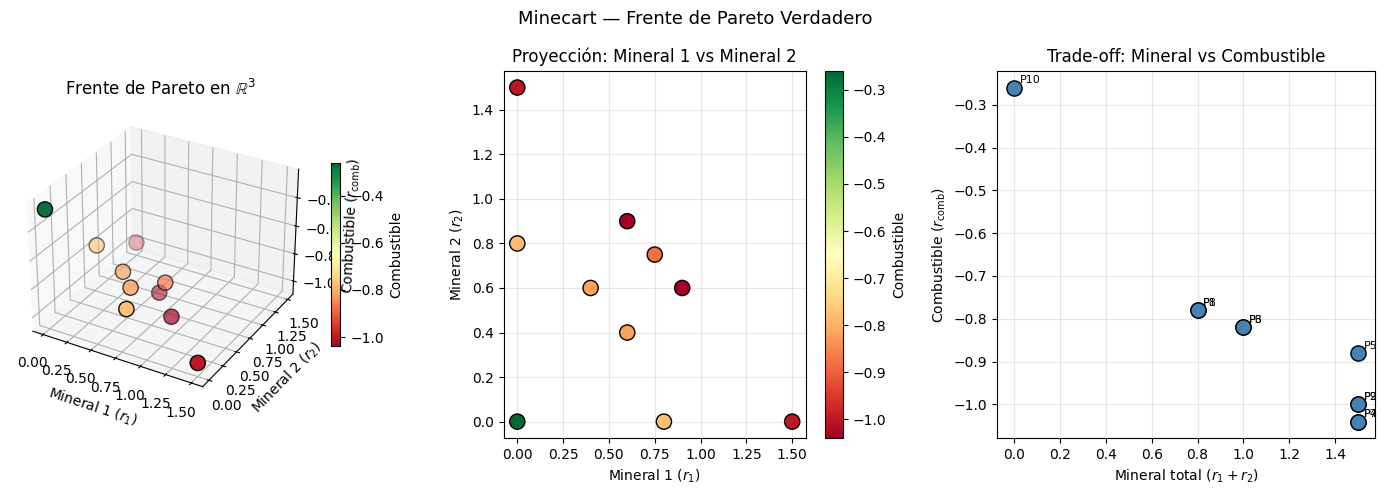

In [5]:
env_pf = mo_gym.make(ENV_ID)
TRUE_PARETO = np.array(env_pf.unwrapped.pareto_front(gamma=GAMMA))
env_pf.close()

print(f'Frente de Pareto verdadero (gamma={GAMMA}):')
print(f'  {len(TRUE_PARETO)} puntos Pareto-óptimos')
print()
print(f'  {"Punto":>6} {"Mineral1 ($r_1$)":>18} {"Mineral2 ($r_2$)":>18} {"Combustible":>14}')
print('  ' + '-' * 62)
for i, pt in enumerate(TRUE_PARETO):
    print(f'  {i+1:>6} {pt[0]:>18.4f} {pt[1]:>18.4f} {pt[2]:>14.4f}')

fig = plt.figure(figsize=(14, 5))

ax3 = fig.add_subplot(131, projection='3d')
sc3 = ax3.scatter(TRUE_PARETO[:,0], TRUE_PARETO[:,1], TRUE_PARETO[:,2],
                  c=TRUE_PARETO[:,2], cmap='RdYlGn', s=120, edgecolors='black', zorder=5)
ax3.set_xlabel('Mineral 1 ($r_1$)'); ax3.set_ylabel('Mineral 2 ($r_2$)')
ax3.set_zlabel('Combustible ($r_\mathrm{comb}$)')
ax3.set_title('Frente de Pareto en $\mathbb{R}^3$')
plt.colorbar(sc3, ax=ax3, label='Combustible', shrink=0.5)

ax1 = fig.add_subplot(132)
sc1 = ax1.scatter(TRUE_PARETO[:,0], TRUE_PARETO[:,1],
                  c=TRUE_PARETO[:,2], cmap='RdYlGn', s=120, edgecolors='black', zorder=5)
ax1.set_xlabel('Mineral 1 ($r_1$)'); ax1.set_ylabel('Mineral 2 ($r_2$)')
ax1.set_title('Proyección: Mineral 1 vs Mineral 2')
plt.colorbar(sc1, ax=ax1, label='Combustible')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(133)
total_mineral = TRUE_PARETO[:,0] + TRUE_PARETO[:,1]
ax2.scatter(total_mineral, TRUE_PARETO[:,2],
            c='steelblue', s=120, edgecolors='black', zorder=5)
for i, (tm, fc) in enumerate(zip(total_mineral, TRUE_PARETO[:,2])):
    ax2.annotate(f'P{i+1}', (tm, fc), xytext=(4, 3), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Mineral total ($r_1 + r_2$)'); ax2.set_ylabel('Combustible ($r_\mathrm{comb}$)')
ax2.set_title('Trade-off: Mineral vs Combustible')
ax2.grid(alpha=0.3)

plt.suptitle('Minecart — Frente de Pareto Verdadero', fontsize=13)
plt.tight_layout()
plt.savefig('videos/minecart_pareto_true.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Algoritmo 1: PCN (Pareto Conditioned Network)

PCN (Reymond et al., 2022) aprende una red neuronal condicionada en el **retorno objetivo deseado** $\mathbf{d} \in \mathbb{R}^3$. Al evaluar con distintos $\mathbf{d}$, obtenemos distintas políticas del frente.

### Parámetros para Minecart

| Parámetro | Valor | Justificación |
|---|---|---|
| `scaling_factor` | `[1.0, 1.0, 0.1, 0.1]` | Combustible y horizonte con menor peso |
| `ref_point` | `[-1, -1, -200]` | Peor retorno posible (cero mineral, combustible máximo) |
| `max_return` | `[1.5, 1.5, 0.0]` | Máximo mineral posible, sin combustible |

In [6]:
from morl_baselines.multi_policy.pcn.pcn import PCN

REF_POINT  = np.array([-1.0, -1.0, -200.0])
MAX_RETURN = np.array([1.5, 1.5, 0.0])
PCN_STEPS  = 8000

print('Configurando PCN para Minecart...')
print(f'  ref_point  = {REF_POINT}')
print(f'  max_return = {MAX_RETURN}')
print(f'  timesteps  = {PCN_STEPS:,}  (demo — convergencia completa ~1M)')

env_pcn = mo_gym.make(ENV_ID)
env_pcn = MORecordEpisodeStatistics(env_pcn, gamma=GAMMA)
eval_env_pcn = mo_gym.make(ENV_ID)

agent_pcn = PCN(
    env_pcn,
    scaling_factor=np.array([1.0, 1.0, 0.1, 0.1]),
    log=False,
)

print('\nEntrenando PCN...')
agent_pcn.train(
    PCN_STEPS,
    eval_env=eval_env_pcn,
    ref_point=REF_POINT,
    max_return=MAX_RETURN,
    max_buffer_size=200,
)
print('Entrenamiento PCN completado.')
env_pcn.close()
eval_env_pcn.close()

Configurando PCN para Minecart...
  ref_point  = [  -1.   -1. -200.]
  max_return = [1.5 1.5 0. ]
  timesteps  = 8,000  (demo — convergencia completa ~1M)



Entrenando PCN...


step 5250 	 return [  0.565      0.185    -10.850016], ([0.6542362  0.37818646 6.7501707 ]) 	 loss 1.792E+00 	 horizons 146.0


step 6388 	 return [ 0.24000001  0.44       -8.566007  ], ([0.36864617 0.4938623  4.8918476 ]) 	 loss 1.789E+00 	 horizons 113.8


step 8566 	 return [  0.36499998   0.475      -15.876033  ], ([0.36813718 0.39003205 8.726738  ]) 	 loss 1.787E+00 	 horizons 217.8


Entrenamiento PCN completado.


### Evaluación PCN — Overlay sobre el Frente Verdadero

Evaluando PCN (5 episodios por configuración):
  Retorno objetivo                  r_1      r_2     r_comb
  ----------------------------------------------------------
  Máximo mineral                  0.460    0.140     -8.880
  Balance medio                   0.216    0.084     -8.852


  Más mineral 1                   0.180    0.280    -11.316


  Más mineral 2                   0.244    0.456    -12.664
  Ahorro combustible              0.000    0.000    -10.116


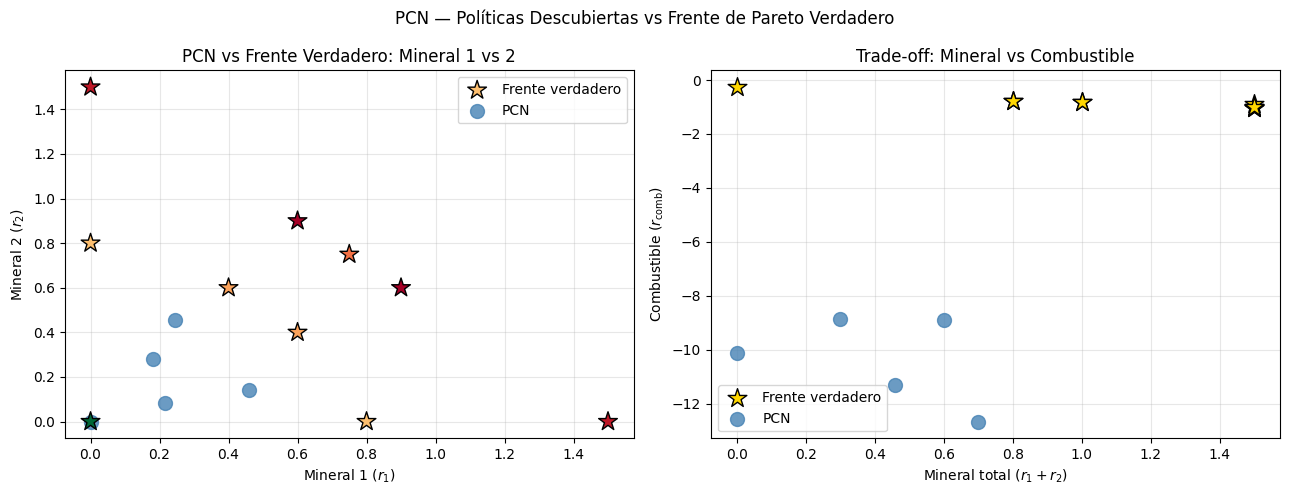

In [7]:
# Retornos objetivo para PCN: distintos trade-offs mineral vs combustible
PCN_EVAL_CONFIGS = [
    (np.array([1.0, 1.0, -20.0]),  'Máximo mineral'),
    (np.array([0.5, 0.5, -10.0]),  'Balance medio'),
    (np.array([1.2, 0.3, -15.0]),  'Más mineral 1'),
    (np.array([0.3, 1.2, -15.0]),  'Más mineral 2'),
    (np.array([0.8, 0.8, -5.0]),   'Ahorro combustible'),
]

print('Evaluando PCN (5 episodios por configuración):')
print(f'  {"Retorno objetivo":<28} {"r_1":>8} {"r_2":>8} {"r_comb":>10}')
print('  ' + '-' * 58)

pcn_pts = []
for desired_return, label in PCN_EVAL_CONFIGS:
    returns = []
    env_ev = mo_gym.make(ENV_ID)
    for _ in range(5):
        obs_ev, _ = env_ev.reset()
        r_cumul = np.zeros(3)
        done_ev = False
        step_ev = 0
        while not done_ev and step_ev < 300:
            try:
                action_ev = agent_pcn.eval(obs_ev, desired_return)
            except Exception:
                action_ev = env_ev.action_space.sample()
            obs_ev, rew_ev, term_ev, trunc_ev, _ = env_ev.step(action_ev)
            r_cumul += rew_ev
            done_ev = term_ev or trunc_ev
            step_ev += 1
        returns.append(r_cumul)
    env_ev.close()
    mean_r = np.mean(returns, axis=0)
    pcn_pts.append(mean_r)
    print(f'  {label:<28} {mean_r[0]:>8.3f} {mean_r[1]:>8.3f} {mean_r[2]:>10.3f}')

pcn_pts = np.array(pcn_pts)

# Overlay sobre frente verdadero
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
sc_true = ax1.scatter(TRUE_PARETO[:,0], TRUE_PARETO[:,1],
                      c=TRUE_PARETO[:,2], cmap='RdYlGn', s=200,
                      marker='*', edgecolors='black', zorder=6, label='Frente verdadero')
ax1.scatter(pcn_pts[:,0], pcn_pts[:,1],
            c='steelblue', s=100, marker='o', alpha=0.8, zorder=5, label='PCN')
ax1.set_xlabel('Mineral 1 ($r_1$)'); ax1.set_ylabel('Mineral 2 ($r_2$)')
ax1.set_title('PCN vs Frente Verdadero: Mineral 1 vs 2')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[1]
total_true = TRUE_PARETO[:,0] + TRUE_PARETO[:,1]
total_pcn  = pcn_pts[:,0] + pcn_pts[:,1]
ax2.scatter(total_true, TRUE_PARETO[:,2], c='gold', s=200, marker='*',
            edgecolors='black', zorder=6, label='Frente verdadero')
ax2.scatter(total_pcn, pcn_pts[:,2], c='steelblue', s=100, marker='o',
            alpha=0.8, zorder=5, label='PCN')
ax2.set_xlabel('Mineral total ($r_1 + r_2$)'); ax2.set_ylabel('Combustible ($r_\mathrm{comb}$)')
ax2.set_title('Trade-off: Mineral vs Combustible')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('PCN — Políticas Descubiertas vs Frente de Pareto Verdadero', fontsize=12)
plt.tight_layout()
plt.savefig('videos/minecart_pcn_eval.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
print('Grabando video del agente PCN (balance mineral)...')
pcn_target = np.array([1.0, 1.0, -20.0])

def pcn_policy(obs):
    try:
        return agent_pcn.eval(obs, pcn_target)
    except Exception:
        return np.random.randint(6)

frames_pcn, r_pcn = record_episode(ENV_ID, pcn_policy, 'videos/minecart_pcn_demo', fps=10)
if frames_pcn:
    imageio.mimsave('resources/agent_gifs/minecart_pcn.gif', frames_pcn, fps=10, loop=0)
    print('GIF guardado: resources/agent_gifs/minecart_pcn.gif')
    writer = imageio.get_writer('resources/agent_videos/minecart_best.mp4', fps=10)
    for f in frames_pcn:
        writer.append_data(f)
    writer.close()
    print('MP4 guardado: resources/agent_videos/minecart_best.mp4')
show_video('videos/minecart_pcn_demo')

Grabando video del agente PCN (balance mineral)...


  Video guardado: videos/minecart_pcn_demo.mp4  (51 pasos, r=[ 0.    0.   -3.52])


GIF guardado: resources/agent_gifs/minecart_pcn.gif
MP4 guardado: resources/agent_videos/minecart_best.mp4


## 6. Análisis de Parámetros — PCN

### `scaling_factor` para Minecart

En Minecart, el combustible ($r_\text{comb}$) tiene una escala muy diferente a los minerales ($r_1, r_2$).
Un `scaling_factor` mal calibrado puede hacer que la red ignore el combustible o los minerales.

Comparando scaling_factor en PCN (2000 pasos cada uno)...


  Estándar [1,1,0.1,0.1]              mineral=0.000  comb=-13.3
  Comb. igual [1,1,1,0.1]             mineral=0.300  comb=-4.9


  Énfasis mineral [2,2,0.1,0.1]       mineral=0.900  comb=-12.4


  Reducido [0.5,0.5,0.5,0.1]          mineral=0.300  comb=-10.4


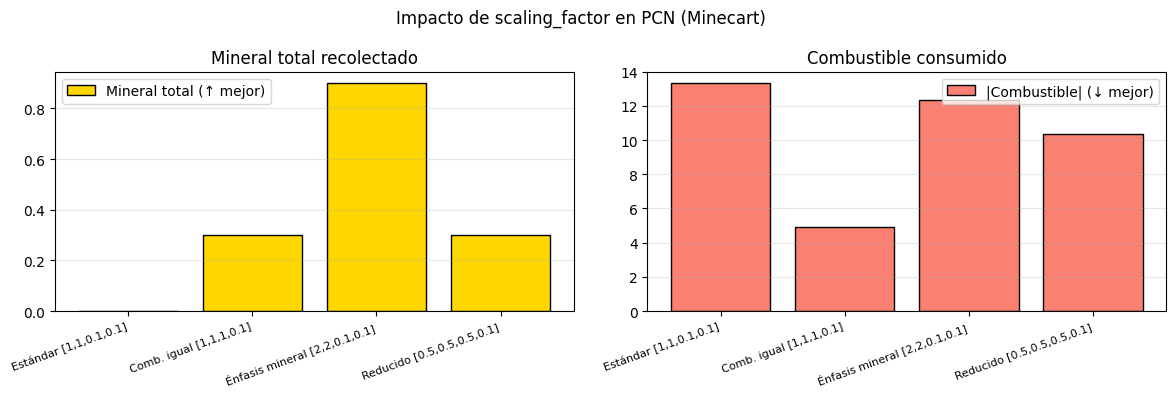

In [9]:
SCALING_TESTS = [
    (np.array([1.0, 1.0, 0.1, 0.1]), 'Estándar [1,1,0.1,0.1]'),
    (np.array([1.0, 1.0, 1.0, 0.1]), 'Comb. igual [1,1,1,0.1]'),
    (np.array([2.0, 2.0, 0.1, 0.1]), 'Énfasis mineral [2,2,0.1,0.1]'),
    (np.array([0.5, 0.5, 0.5, 0.1]), 'Reducido [0.5,0.5,0.5,0.1]'),
]

scaling_results = {}
print('Comparando scaling_factor en PCN (2000 pasos cada uno)...')
d_test = np.array([0.8, 0.8, -20.0])
for sf, label in SCALING_TESTS:
    env_sf = mo_gym.make(ENV_ID)
    env_sf = MORecordEpisodeStatistics(env_sf, gamma=GAMMA)
    ev_sf  = mo_gym.make(ENV_ID)
    ag_sf  = PCN(env_sf, scaling_factor=sf, log=False)
    ag_sf.train(2000, eval_env=ev_sf, ref_point=REF_POINT,
                max_return=MAX_RETURN, max_buffer_size=200)
    env_sf.close(); ev_sf.close()

    env_ev2 = mo_gym.make(ENV_ID)
    pts = []
    for _ in range(5):
        obs_sf, _ = env_ev2.reset()
        r_sf = np.zeros(3); done_sf = False; step_sf = 0
        while not done_sf and step_sf < 300:
            try:
                a_sf = ag_sf.eval(obs_sf, d_test)
            except Exception:
                a_sf = env_ev2.action_space.sample()
            obs_sf, rew_sf, term_sf, trunc_sf, _ = env_ev2.step(a_sf)
            r_sf += rew_sf; done_sf = term_sf or trunc_sf; step_sf += 1
        pts.append(r_sf)
    env_ev2.close()
    mean_pt = np.mean(pts, axis=0)
    scaling_results[label] = mean_pt
    print(f'  {label:<35} mineral={mean_pt[0]+mean_pt[1]:.3f}  comb={mean_pt[2]:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_sf = list(scaling_results.keys())
minerals = [v[0] + v[1] for v in scaling_results.values()]
fuels    = [abs(v[2]) for v in scaling_results.values()]
x = np.arange(len(labels_sf))
w = 0.35
axes[0].bar(x, minerals, color='gold', edgecolor='black', label='Mineral total (↑ mejor)')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_sf, rotation=20, ha='right', fontsize=8)
axes[0].set_title('Mineral total recolectado'); axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x, fuels, color='salmon', edgecolor='black', label='|Combustible| (↓ mejor)')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_sf, rotation=20, ha='right', fontsize=8)
axes[1].set_title('Combustible consumido'); axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Impacto de scaling_factor en PCN (Minecart)', fontsize=12)
plt.tight_layout()
plt.savefig('videos/minecart_scaling_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Algoritmo 2: GPI-LS Neuronal (GPI-PD)

### GPI-LS en Minecart Estocástico

Usamos la versión **estocástica** (`minecart-v0`) para GPI-LS, que añade ruido en las transiciones físicas y en las recompensas. Esto exige que el agente aprenda políticas robustas que funcionen bien en promedio, no solo en trayectorias ideales.

$$\text{GPI}(s, \mathbf{w}) = \arg\max_a \max_{\pi \in \Pi} \mathbf{w}^\top \mathbf{Q}^\pi(s, a)$$

Los vectores de pesos $\mathbf{w} = [w_1, w_2, w_\text{comb}]$ son seleccionados automáticamente por **Linear Support**.

> Nota: para Minecart estocástico se recomienda `per=True` (Prioritized Experience Replay) para mejorar la eficiencia de muestreo.

In [10]:
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPILS

GAMMA_GPI   = 0.98
GPILS_STEPS = 5000

print('Configurando GPI-LS para Minecart (estocástico)...')
print(f'  env       = {ENV_ID_STOC}')
print(f'  gamma     = {GAMMA_GPI}')
print(f'  timesteps = {GPILS_STEPS:,}  (demo — convergencia completa ~200k)')

env_gpils = mo_gym.make(ENV_ID_STOC)
env_gpils = MORecordEpisodeStatistics(env_gpils, gamma=GAMMA_GPI)
eval_env_gpils = mo_gym.make(ENV_ID_STOC)

agent_gpils = GPILS(
    env_gpils,
    per=True,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    epsilon_decay_steps=GPILS_STEPS,
    target_net_update_freq=200,
    gradient_updates=10,
    log=False,
)

print('\nEntrenando GPI-LS...')
agent_gpils.train(
    total_timesteps=GPILS_STEPS,
    eval_env=eval_env_gpils,
    ref_point=np.array([-1.0, -1.0, -200.0]),
)
print('Entrenamiento GPI-LS completado.')
env_gpils.close()
eval_env_gpils.close()

Configurando GPI-LS para Minecart (estocástico)...
  env       = minecart-v0
  gamma     = 0.98
  timesteps = 5,000  (demo — convergencia completa ~200k)

Entrenando GPI-LS...


Entrenamiento GPI-LS completado.


### Evaluación GPI-LS — Overlay sobre Frente Verdadero

In [11]:
GPILS_EVAL_WEIGHTS = [
    (np.array([0.45, 0.45, 0.1]),  'Balance mineral'),
    (np.array([0.5,  0.5,  0.0]),  'Solo mineral'),
    (np.array([0.7,  0.2,  0.1]),  'Prioriza mineral 1'),
    (np.array([0.2,  0.7,  0.1]),  'Prioriza mineral 2'),
    (np.array([0.1,  0.1,  0.8]),  'Ahorra combustible'),
]

print('Evaluando GPI-LS (5 episodios por configuración):')
print(f'  {"Preferencia":<30} {"r_1":>8} {"r_2":>8} {"r_comb":>10}')
print('  ' + '-' * 60)

gpils_pts = []
for weight, label in GPILS_EVAL_WEIGHTS:
    returns_g = []
    env_gev = mo_gym.make(ENV_ID_STOC)
    for _ in range(5):
        obs_gev, _ = env_gev.reset()
        r_g = np.zeros(3); done_g = False; step_g = 0
        while not done_g and step_g < 300:
            try:
                action_g = agent_gpils.eval(obs_gev, weight)
            except Exception:
                action_g = env_gev.action_space.sample()
            obs_gev, rew_g, term_g, trunc_g, _ = env_gev.step(action_g)
            r_g += rew_g; done_g = term_g or trunc_g; step_g += 1
        returns_g.append(r_g)
    env_gev.close()
    mean_g = np.mean(returns_g, axis=0)
    gpils_pts.append(mean_g)
    print(f'  {label:<30} {mean_g[0]:>8.3f} {mean_g[1]:>8.3f} {mean_g[2]:>10.3f}')

gpils_pts = np.array(gpils_pts)

Evaluando GPI-LS (5 episodios por configuración):
  Preferencia                         r_1      r_2     r_comb
  ------------------------------------------------------------
  Balance mineral                   0.133    0.167    -14.748


  Solo mineral                      0.136    0.164     -8.024
  Prioriza mineral 1                0.170    0.130     -8.008


  Prioriza mineral 2                0.332    0.568    -13.132
  Ahorra combustible                0.076    0.156     -6.564


In [12]:
print('Grabando video del agente GPI-LS...')
gpils_w_demo = np.array([0.45, 0.45, 0.1])

def gpils_policy(obs):
    try:
        return agent_gpils.eval(obs, gpils_w_demo)
    except Exception:
        return np.random.randint(6)

frames_gpils, r_gpils = record_episode(ENV_ID_STOC, gpils_policy, 'videos/minecart_gpils_demo', fps=10)
show_video('videos/minecart_gpils_demo')

Grabando video del agente GPI-LS...


  Video guardado: videos/minecart_gpils_demo.mp4  (137 pasos, r=[  0.     0.   -11.04])


## 8. Comparación Final: PCN vs GPI-LS

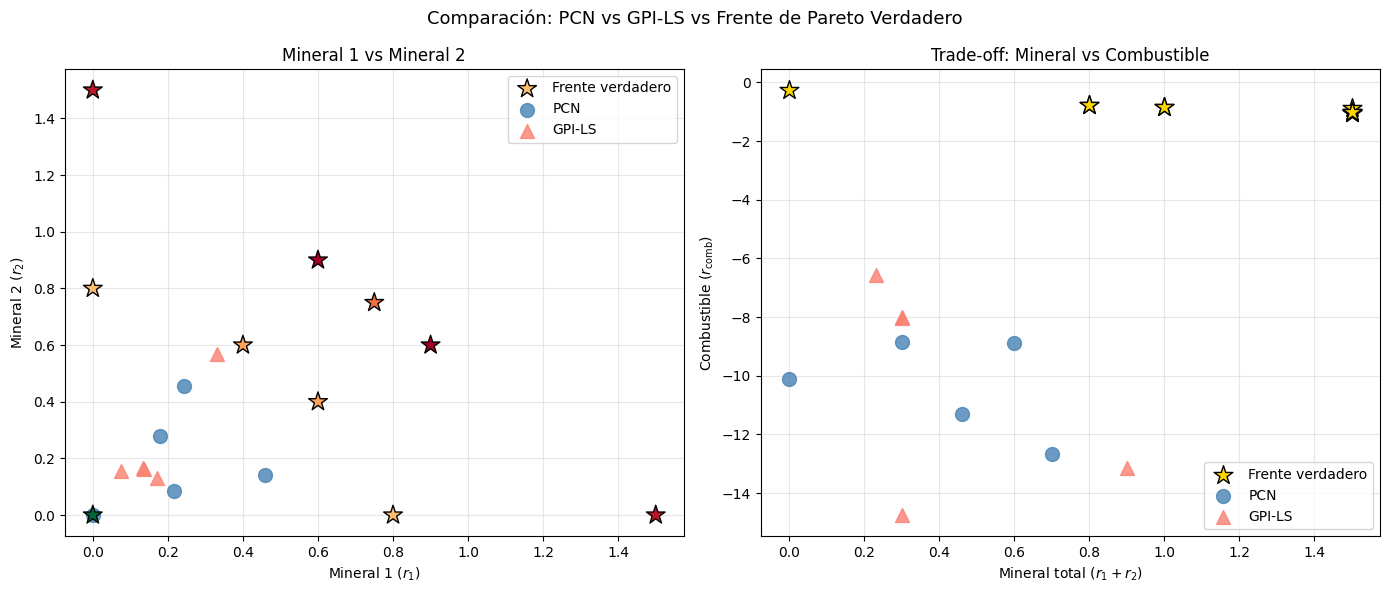


Resumen (media de evaluaciones):
  Algoritmo         r_1      r_2     r_comb   Mineral total
  ----------------------------------------------------------
  PCN             0.220    0.192    -10.366           0.412
  GPI-LS          0.169    0.237    -10.095           0.406
     Verdadero (media frente)
                  0.555    0.555     -0.842           1.110


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mineral 1 vs Mineral 2
ax = axes[0]
sc_t = ax.scatter(TRUE_PARETO[:,0], TRUE_PARETO[:,1],
                  c=TRUE_PARETO[:,2], cmap='RdYlGn', s=200,
                  marker='*', edgecolors='black', zorder=6, label='Frente verdadero')
if len(pcn_pts):
    ax.scatter(pcn_pts[:,0], pcn_pts[:,1], c='steelblue', s=100,
               marker='o', alpha=0.8, zorder=5, label='PCN')
if len(gpils_pts):
    ax.scatter(gpils_pts[:,0], gpils_pts[:,1], c='salmon', s=100,
               marker='^', alpha=0.8, zorder=5, label='GPI-LS')
ax.set_xlabel('Mineral 1 ($r_1$)'); ax.set_ylabel('Mineral 2 ($r_2$)')
ax.set_title('Mineral 1 vs Mineral 2')
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Mineral total vs Combustible
ax2 = axes[1]
total_true  = TRUE_PARETO[:,0] + TRUE_PARETO[:,1]
ax2.scatter(total_true, TRUE_PARETO[:,2], c='gold', s=200, marker='*',
            edgecolors='black', zorder=6, label='Frente verdadero')
if len(pcn_pts):
    total_pcn = pcn_pts[:,0] + pcn_pts[:,1]
    ax2.scatter(total_pcn, pcn_pts[:,2], c='steelblue', s=100,
                marker='o', alpha=0.8, zorder=5, label='PCN')
if len(gpils_pts):
    total_gpils = gpils_pts[:,0] + gpils_pts[:,1]
    ax2.scatter(total_gpils, gpils_pts[:,2], c='salmon', s=100,
                marker='^', alpha=0.8, zorder=5, label='GPI-LS')
ax2.set_xlabel('Mineral total ($r_1 + r_2$)'); ax2.set_ylabel('Combustible ($r_\mathrm{comb}$)')
ax2.set_title('Trade-off: Mineral vs Combustible')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Comparación: PCN vs GPI-LS vs Frente de Pareto Verdadero', fontsize=13)
plt.tight_layout()
plt.savefig('videos/minecart_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nResumen (media de evaluaciones):')
print(f'  {"Algoritmo":<12} {"r_1":>8} {"r_2":>8} {"r_comb":>10} {"Mineral total":>15}')
print('  ' + '-' * 58)
for pts, name in [(pcn_pts, 'PCN'), (gpils_pts, 'GPI-LS')]:
    if len(pts):
        m = pts.mean(axis=0)
        print(f'  {name:<12} {m[0]:>8.3f} {m[1]:>8.3f} {m[2]:>10.3f} {m[0]+m[1]:>15.3f}')
print(f'  {"Verdadero":>12} (media frente)')
tm = TRUE_PARETO.mean(axis=0)
print(f'  {"":>12} {tm[0]:>8.3f} {tm[1]:>8.3f} {tm[2]:>10.3f} {tm[0]+tm[1]:>15.3f}')

## 9. Conclusiones

### Minecart — Lecciones Aprendidas

**1. Minecart tiene frente de Pareto analítico**
A diferencia de Mountain Car, podemos obtener `env.unwrapped.pareto_front(gamma)` y medir exactamente cuánto se aleja cada algoritmo del óptimo real. Esto hace de Minecart un benchmark más riguroso.

**2. PCN condiciona en retorno absoluto; GPI-LS en pesos relativos**
- PCN: necesitas saber que el máximo mineral posible es ~1.5 para especificar $\mathbf{d}$ bien calibrado
- GPI-LS: basta con $\mathbf{w} = [0.5, 0.5, 0.0]$ para decir "maximiza mineral por igual" — más intuitivo

**3. Minecart estocástico exige robustez**
La versión `minecart-v0` añade ruido. GPI-LS con PER (Prioritized Experience Replay) maneja mejor la varianza al priorizar transiciones informativas. PCN es menos sensible al ruido al condicionar en retorno objetivo.

**4. El trade-off mineral-combustible es fundamental**
Todos los puntos del frente verdadero muestran una correlación negativa entre mineral total y combustible: más mineral → más desplazamiento → más combustible. Este trade-off es inevitable y constituye el núcleo del problema MORL de Minecart.

**5. Pasos de convergencia**

| Algoritmo | Pasos para convergencia en Minecart |
|---|---|
| PCN | ~1,000,000 |
| GPI-LS (GPI-PD) | ~200,000 |

### Referencias

- Reymond et al. (2022). *Pareto Conditioned Networks.* — PCN
- Alegre et al. (2023). *MORL-Baselines: Multi-Objective Reinforcement Learning Algorithms.* — GPI-LS/GPI-PD
- MO-Gymnasium Minecart: https://mo-gymnasium.farama.org/environments/minecart-deterministic